### Plasmid Part Synteny and Co-occurrence Analysis

#### 1. Function of this notebook
This notebook analyzes and compares the structural organization of parts (genetic elements) in real Addgene plasmids 
versus PlasmidGPT-generated plasmids. The analysis includes:
- Part count comparison (promoter, CDS, terminator, etc.)
- Part co-occurrence patterns (which parts appear together)
- Synteny analysis (sequential order of parts)
- Transition probability matrices (current part → next part)
- Distance distributions between consecutive parts
- Relative position preferences for each part type

#### 2. Input and Output
**Input files (in the same folder):**
- real_*.csv: pLannotate annotation results for Addgene plasmids (one CSV per plasmid)
- gen_*.csv: pLannotate annotation results for generated plasmids (one CSV per plasmid)

Each CSV file should contain columns: 'Type', 'start location', 'end location', 'sseqid'

**Output:**
- Part count comparison bar plot
- Co-occurrence scatter plot with R² correlation
- Transition probability heatmaps (real vs generated)
- Transition correlation scatter plot
- Part distance distribution histograms
- Position preference violin plots

#### 3. Time estimation
- Data loading and analysis: ~1-5 minutes (depending on number of plasmids)
- Total runtime: ~5-10 minutes

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from itertools import combinations

In [28]:
# Configuration - all CSV files are in the same folder
DATA_FOLDER = "./pLannotate_csv"  # Modify this to your data folder path
MAX_PLASMID_LENGTH = 20000  # Filter out plasmids larger than this
MAX_FILES = 500  # Maximum number of files to analyze per category

In [29]:
# Function to calculate co-occurrence matrix
def calculate_cooccurrence(folder_path, file_prefix, max_files=50000):
    """Calculate co-occurrence matrix for parts in plasmids."""
    cooccurrence_matrix = {}
    file_count = 0
    
    for file_name in os.listdir(folder_path):
        if file_name.startswith(file_prefix) and file_name.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_path, file_name))
            
            # Skip large plasmids
            if 'start location' in df.columns and max(df['start location']) >= MAX_PLASMID_LENGTH:
                continue
                
            file_count += 1
            if file_count > max_files:
                break
            
            if 'Type' in df.columns:
                # Get unique parts in this plasmid
                parts_in_plasmid = df['Type'].unique()
                
                # Count co-occurrences
                for part1, part2 in combinations(sorted(parts_in_plasmid), 2):
                    pair = (part1, part2)
                    if pair not in cooccurrence_matrix:
                        cooccurrence_matrix[pair] = 0
                    cooccurrence_matrix[pair] += 1
    
    # Normalize by number of files
    for pair in cooccurrence_matrix:
        cooccurrence_matrix[pair] = cooccurrence_matrix[pair] / file_count
    
    return cooccurrence_matrix, file_count

In [30]:
# Calculate co-occurrence for both datasets
print("Calculating co-occurrence for real plasmids...")
cooccur_real, n_real = calculate_cooccurrence(DATA_FOLDER, 'real_', max_files=50000)
print(f"Analyzed {n_real} real plasmids")

print("Calculating co-occurrence for generated plasmids...")
cooccur_gen, n_gen = calculate_cooccurrence(DATA_FOLDER, 'gen_', max_files=50000)
print(f"Analyzed {n_gen} generated plasmids")

Calculating co-occurrence for real plasmids...
Analyzed 200 real plasmids
Calculating co-occurrence for generated plasmids...
Analyzed 155 generated plasmids


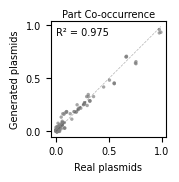


Co-occurrence correlation R² = 0.975


In [31]:
# Plot co-occurrence comparison
def plot_cooccurrence_comparison(cooccur_real, cooccur_gen, top_n=2000):
    """Compare co-occurrence frequencies between real and generated plasmids."""
    
    # Get all unique pairs
    all_pairs = set(list(cooccur_real.keys()) + list(cooccur_gen.keys()))
    
    # Sort pairs by total frequency
    pair_frequencies = {}
    for pair in all_pairs:
        freq_real = cooccur_real.get(pair, 0)
        freq_gen = cooccur_gen.get(pair, 0)
        pair_frequencies[pair] = freq_real + freq_gen
    
    # Get top N pairs
    top_pairs = sorted(pair_frequencies.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_pairs = [pair[0] for pair in top_pairs]
    
    # Prepare data for plotting
    real_freqs = [cooccur_real.get(pair, 0) for pair in top_pairs]
    gen_freqs = [cooccur_gen.get(pair, 0) for pair in top_pairs]
    
    # Calculate correlation
    r, p_value = pearsonr(real_freqs, gen_freqs)
    r2 = r ** 2
    
    # Plot
    plt.figure(figsize=(1.5, 1.5))
    plt.scatter(real_freqs, gen_freqs, s=6, alpha=0.7, color='gray', edgecolors='none')
    
    # Add diagonal line
    max_val = max(max(real_freqs), max(gen_freqs))
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=0.5)
    
    # Add R² annotation
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
             fontsize=7, verticalalignment='top')
    
    plt.xlabel('Real plasmids', fontsize=7)
    plt.ylabel('Generated plasmids', fontsize=7)
    plt.xticks([0, 0.5, 1.0], fontsize=7)
    plt.yticks([0, 0.5, 1.0], fontsize=7)
    plt.title('Part Co-occurrence', fontsize=7, pad=3)
    plt.gca().set_aspect('equal', adjustable='box')
    
    return r2, top_pairs

r2_cooccur, top_pairs = plot_cooccurrence_comparison(cooccur_real, cooccur_gen, top_n=2000)
plt.show()

print(f"\nCo-occurrence correlation R² = {r2_cooccur:.3f}")

In [32]:
# Function to analyze synteny patterns
def analyze_synteny(folder_path, file_prefix, max_files=5000):
    """
    Analyze synteny patterns: part order and distances.
    
    Returns:
        transition_counts: Dict of (current_part, next_part) -> normalized count
        part_distances: Dict of (part1, part2) -> list of distances
        position_preferences: Dict of part_type -> list of relative positions
    """
    transition_counts = {}
    part_distances = {}
    position_preferences = {}
    file_count = 0
    
    for file_name in os.listdir(folder_path):
        if file_name.startswith(file_prefix) and file_name.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_path, file_name))
            
            # Skip large plasmids
            if 'start location' in df.columns and max(df['start location']) >= MAX_PLASMID_LENGTH:
                continue
                
            file_count += 1
            if file_count > max_files:
                break
            
            if 'Type' in df.columns and 'start location' in df.columns:
                # Sort by position
                df = df.sort_values('start location')
                
                # Get plasmid length
                plasmid_length = max(df['end location']) if 'end location' in df.columns else max(df['start location'])
                
                # Analyze transitions between consecutive parts
                parts = df['Type'].tolist()
                positions = df['start location'].tolist()
                
                for i in range(len(parts) - 1):
                    transition = (parts[i], parts[i+1])
                    if transition not in transition_counts:
                        transition_counts[transition] = 0
                    transition_counts[transition] += 1
                    
                    # Calculate distance
                    distance = positions[i+1] - positions[i]
                    if transition not in part_distances:
                        part_distances[transition] = []
                    part_distances[transition].append(distance)
                
                # Calculate relative positions
                for i, part in enumerate(parts):
                    rel_position = positions[i] / plasmid_length
                    if part not in position_preferences:
                        position_preferences[part] = []
                    position_preferences[part].append(rel_position)
    
    # Normalize transition counts
    total_transitions = sum(transition_counts.values())
    if total_transitions > 0:
        for key in transition_counts:
            transition_counts[key] = transition_counts[key] / total_transitions
    
    return transition_counts, part_distances, position_preferences

In [33]:
#Analyze synteny for both datasets
print("Analyzing synteny for real plasmids...")
trans_real, dist_real, pos_real = analyze_synteny(DATA_FOLDER, 'real_', max_files=5000)

print("Analyzing synteny for generated plasmids...")
trans_gen, dist_gen, pos_gen = analyze_synteny(DATA_FOLDER, 'gen_', max_files=5000)

Analyzing synteny for real plasmids...
Analyzing synteny for generated plasmids...


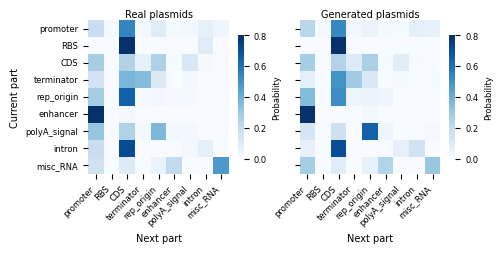

In [34]:
def plot_synteny_heatmap(transitions_real, transitions_gen):
    """Plot transition probability heatmaps."""
    
    # Get common parts for consistent ordering
    all_parts = set()
    for (p1, p2) in list(transitions_real.keys()) + list(transitions_gen.keys()):
        all_parts.add(p1)
        all_parts.add(p2)
    
    # Focus on most common parts
    common_parts = ['promoter', 'RBS', 'CDS', 'terminator', 'rep_origin', 
                   'enhancer', 'polyA_signal', 'intron', 'misc_RNA']
    common_parts = [p for p in common_parts if p in all_parts]
    
    # Create matrices
    n = len(common_parts)
    matrix_real = np.zeros((n, n))
    matrix_gen = np.zeros((n, n))
    
    for i, part1 in enumerate(common_parts):
        for j, part2 in enumerate(common_parts):
            matrix_real[i, j] = transitions_real.get((part1, part2), 0)
            matrix_gen[i, j] = transitions_gen.get((part1, part2), 0)
    
    # Normalize rows
    matrix_real = matrix_real / (matrix_real.sum(axis=1, keepdims=True) + 1e-10)
    matrix_gen = matrix_gen / (matrix_gen.sum(axis=1, keepdims=True) + 1e-10)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2))
    
    sns.heatmap(matrix_real, xticklabels=common_parts, yticklabels=common_parts,
                cmap='Blues', cbar=True, ax=ax1, vmin=0, vmax=0.8,
                cbar_kws={'label': 'Probability', 'shrink': 0.8})
    ax1.set_title('Real plasmids', fontsize=7, pad=2)
    ax1.set_xlabel('Next part', fontsize=7)
    ax1.set_ylabel('Current part', fontsize=7)
    ax1.tick_params(axis='both', labelsize=6)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
    
    sns.heatmap(matrix_gen, xticklabels=common_parts, yticklabels=common_parts,
                cmap='Blues', cbar=True, ax=ax2, vmin=0, vmax=0.8,
                cbar_kws={'label': 'Probability', 'shrink': 0.8})
    ax2.set_title('Generated plasmids', fontsize=7, pad=2)
    ax2.set_xlabel('Next part', fontsize=7)
    ax2.set_ylabel('', fontsize=7)
    ax2.tick_params(axis='both', labelsize=6)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_yticklabels([])
    
    # Adjust colorbar font size
    for ax in [ax1, ax2]:
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=6)
        cbar.set_label('Probability', fontsize=6)
    
    return fig

# Plot synteny heatmaps
fig1 = plot_synteny_heatmap(trans_real, trans_gen)

plt.show()

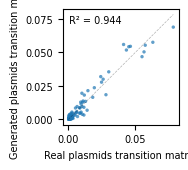


Synteny correlation R² = 0.944, p-value = 7.985e-62


In [35]:
# Plot transition correlation scatter plot
common_transitions = set(trans_real.keys()) & set(trans_gen.keys())
real_probs = [trans_real[t] for t in common_transitions]
gen_probs = [trans_gen[t] for t in common_transitions]

# Calculate correlation
r, p_value = pearsonr(real_probs, gen_probs)
r2 = r ** 2

plt.figure(figsize=(1.5, 1.5))
plt.scatter(real_probs, gen_probs, s=6, alpha=0.7, color='#1f77b4', edgecolors='none')

# Add diagonal line
max_val = max(max(real_probs), max(gen_probs))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, linewidth=0.5)

# Add R² annotation
plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
         fontsize=7, verticalalignment='top')

plt.xlabel('Real plasmids transition matrix', fontsize=7)
plt.ylabel('Generated plasmids transition matrix', fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.title('', fontsize=7, pad=3)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

print(f"\nSynteny correlation R² = {r2:.3f}, p-value = {p_value:.3e}")

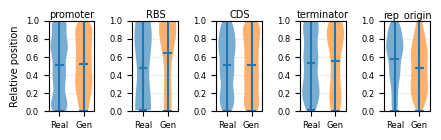

In [36]:
# Function to plot position preferences
def plot_position_preferences(pos_real, pos_gen):
    """Plot relative position preferences for parts."""
    
    key_parts = ['promoter', 'RBS', 'CDS', 'terminator', 'rep_origin']
    key_parts = [p for p in key_parts if p in pos_real and p in pos_gen]
    
    fig, axes = plt.subplots(1, len(key_parts), figsize=(4.5, 1.5))
    
    for idx, part in enumerate(key_parts):
        ax = axes[idx]
        
        if len(pos_real[part]) > 0 and len(pos_gen[part]) > 0:
            data_to_plot = [pos_real[part], pos_gen[part]]
            labels = ['Real', 'Gen']
            
            parts = ax.violinplot(data_to_plot, positions=range(len(data_to_plot)),
                                 widths=0.7, showmeans=True, showmedians=False)
            
            colors = ['#1f77b4', '#ff7f0e']
            for pc, color in zip(parts['bodies'], colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.6)
        
        ax.set_title(part, fontsize=7, pad=2)
        ax.set_ylim([0, 1])
        ax.set_ylabel('Relative position' if idx == 0 else '', fontsize=7)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=6)
        ax.tick_params(axis='y', labelsize=6)
        ax.grid(True, alpha=0.2, axis='y')
    
    plt.tight_layout()
    return fig

# Plot position preferences
fig2 = plot_position_preferences(pos_real, pos_gen)

plt.show()

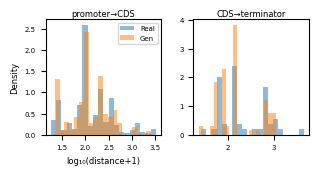

In [37]:
# Function to plot part distance distributions
def plot_part_distance_distributions(dist_real, dist_gen):
    """Compare distance distributions between specific part pairs."""
    
    important_transitions = [
        ('promoter', 'CDS'),
        ('CDS', 'terminator'),
    ]
    
    # Filter to transitions that exist in both datasets
    important_transitions = [(p1, p2) for p1, p2 in important_transitions 
                             if (p1, p2) in dist_real and (p1, p2) in dist_gen]
    
    if len(important_transitions) == 0:
        print("No common transitions found for distance analysis")
        return None
    
    fig, axes = plt.subplots(1, len(important_transitions), figsize=(3.5, 1.5))
    if len(important_transitions) == 1:
        axes = [axes]
    
    for idx, (part1, part2) in enumerate(important_transitions):
        ax = axes[idx]
        
        real_dists = dist_real.get((part1, part2), [])
        gen_dists = dist_gen.get((part1, part2), [])
        
        if len(real_dists) > 0 and len(gen_dists) > 0:
            # Log transform for better visualization
            real_dists_log = np.log10(np.array(real_dists) + 1)
            gen_dists_log = np.log10(np.array(gen_dists) + 1)
            
            # Plot histograms
            ax.hist(real_dists_log, bins=20, alpha=0.5, density=True, 
                   color='#1f77b4', label='Real')
            ax.hist(gen_dists_log, bins=20, alpha=0.5, density=True,
                   color='#ff7f0e', label='Gen')
            
            ax.set_title(f'{part1}→{part2}', fontsize=6, pad=2)
            ax.set_xlabel('log₁₀(distance+1)' if idx == 0 else '', fontsize=6)
            ax.set_ylabel('Density' if idx == 0 else '', fontsize=6)
            ax.tick_params(axis='both', labelsize=5)
            
            if idx == 0:
                ax.legend(fontsize=5, loc='upper right')
            ax.set_box_aspect(1)
    
    return fig

# Plot distance distributions
fig3 = plot_part_distance_distributions(dist_real, dist_gen)
if fig3 is not None:
    plt.show()